In [1]:
from glob import glob

In [2]:
glob("*.csv")

['titanic.csv']

In [3]:
# import dependies
import pandas as pd



In [4]:
df =pd.read_csv("titanic.csv")

# check this missing values

In [5]:
# check this missing values
df.isnull().sum()
"""
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
"""

'\nPassengerId      0\nSurvived         0\nPclass           0\nName             0\nSex              0\nAge            177\nSibSp            0\nParch            0\nTicket           0\nFare             0\nCabin          687\nEmbarked         2\ndtype: int64\n'

In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
# fill the values
df["Age"].fillna(df["Age"].median(),inplace=True)
# Drop Cabin
df.drop('Cabin', axis=1, inplace=True)

# Fill Embarked
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\mages\AppData\Local\Temp\ipykernel_7896\1427016596.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)
C:\Users\mages\AppData\Local\Temp\ipykernel_7896\1427016596.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [11]:
# check this missing values
df.isnull().sum()
"""
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
"""

'\nPassengerId    0\nSurvived       0\nPclass         0\nName           0\nSex            0\nAge            0\nSibSp          0\nParch          0\nTicket         0\nFare           0\nEmbarked       0\ndtype: int64\n'

Step 1: Basic Survival Understanding
How many passengers survived?
How many did not survive?
What is the survival percentage?

# step_1

In [12]:
survived_person = len(df[df["Survived"]==1])
unsurvived_person = len(df[df["Survived"]==0])
survived_person_percentage = (survived_person/df.shape[0])*100
print("step_1")
print("How many passengers survived? \n",survived_person)
print("How many did not survive? \n",unsurvived_person)
print("What is the survival percentage? \n",survived_person_percentage,"%")
"""
output:
How many passengers survived? 
 342
How many did not survive? 
 549
What is the survival percentage? 
 38.38383838383838
"""



step_1
How many passengers survived? 
 342
How many did not survive? 
 549
What is the survival percentage? 
 38.38383838383838 %


'\noutput:\nHow many passengers survived? \n 342\nHow many did not survive? \n 549\nWhat is the survival percentage? \n 38.38383838383838\n'

In [13]:
df.shape[0]

891

Step 2: Survival vs Gender
How many males and females are there?
How many males survived vs not survived?
How many females survived vs not survived?
What is survival percentage for each gender?

In [14]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [15]:
print("How many males and females are there? \n",df.Sex.value_counts())
print("-"*100)
print("How many males survived vs not survived?\n",df[df["Sex"]=="male"]["Survived"].value_counts())
print("-"*100)
print("How many female survived vs not survived?\n",df[df["Sex"]=="female"]["Survived"].value_counts())
print("-"*100)
print("What is survival percentage for each gender ?", df.groupby("Sex")["Survived"].value_counts(normalize=True) * 100)

"""
How many males and females are there? 
 Sex
male      577
female    314
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
How many males survived vs not survived?
 Survived
0    468
1    109
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
How many female survived vs not survived?
 Survived
1    233
0     81
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
What is survival percentage for each gender ? Sex     Survived
female  1           74.203822
        0           25.796178
male    0           81.109185
        1           18.890815
Name: proportion, dtype: float64
"""

How many males and females are there? 
 Sex
male      577
female    314
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
How many males survived vs not survived?
 Survived
0    468
1    109
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
How many female survived vs not survived?
 Survived
1    233
0     81
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
What is survival percentage for each gender ? Sex     Survived
female  1           74.203822
        0           25.796178
male    0           81.109185
        1           18.890815
Name: proportion, dtype: float64


'\nHow many males and females are there? \n Sex\nmale      577\nfemale    314\nName: count, dtype: int64\n----------------------------------------------------------------------------------------------------\nHow many males survived vs not survived?\n Survived\n0    468\n1    109\nName: count, dtype: int64\n----------------------------------------------------------------------------------------------------\nHow many female survived vs not survived?\n Survived\n1    233\n0     81\nName: count, dtype: int64\n----------------------------------------------------------------------------------------------------\nWhat is survival percentage for each gender ? Sex     Survived\nfemale  1           74.203822\n        0           25.796178\nmale    0           81.109185\n        1           18.890815\nName: proportion, dtype: float64\n'

How many passengers are in each class?
How many survived in each class?
What is survival percentage for each class?


In [16]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [39]:
df[df["Survived"]==1]["Pclass"].value_counts()

Pclass
1    136
3    119
2     87
Name: count, dtype: int64

In [ ]:
print("How many passengers are in each class? \n",df["Pclass"].value_counts())
print("-"*100)
print("How many survived in each class? \n",df.groupby("Survived")["Pclass"].value_counts())
print("-"*100)
print("What is survival percentage for each class? \n",df.groupby("Survived")["Pclass"].value_counts(normalize=True)*100)
print("-"*100)
survived_person_value_count_pclass = df[df["Survived"]==1].groupby("Survived")["Pclass"].value_counts(normalize=True)*100
res = survived_person_value_count_pclass.idxmax()
print("Which class had the highest survival rate? \n",res)

"""
How many passengers are in each class? 
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
How many survived in each class? 
 Survived  Pclass
0         3         372
          2          97
          1          80
1         1         136
          3         119
          2          87
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
What is survival percentage for each class? 
 Survived  Pclass
0         3         67.759563
          2         17.668488
          1         14.571949
1         1         39.766082
          3         34.795322
          2         25.438596
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
Which class had the highest survival rate? 
 (np.int64(1), np.int64(1))
"""

How many passengers are in each class? 
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
How many survived in each class? 
 Survived  Pclass
0         3         372
          2          97
          1          80
1         1         136
          3         119
          2          87
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
What is survival percentage for each class? 
 Survived  Pclass
0         3         67.759563
          2         17.668488
          1         14.571949
1         1         39.766082
          3         34.795322
          2         25.438596
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
Which class had the highest survival rate? 
 (np.int64(1), np.int64(1))


In [ ]:
# Correct survival percentage per class
df[df["Survived"]==1]["Pclass"].value_counts(normalize=True)*100
"""
Pclass
1    39.766082
3    34.795322
2    25.438596
"""

Pclass
1    39.766082
3    34.795322
2    25.438596
Name: proportion, dtype: float64

In [ ]:
df.groupby("Pclass")["Survived"].mean() * 100
"""
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

"""

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [ ]:
survived_person_value_count_pclass = df[df["Survived"]==1].groupby("Survived")["Pclass"].value_counts(normalize=True)*100
res = survived_person_value_count_pclass.idxmax()
print(f"Pclass with highest survival: {res}")

Pclass with highest survival: (np.int64(1), np.int64(1))


In [32]:
survivor_pclass_pct = df[df["Survived"]==1]["Pclass"].value_counts(normalize=True) * 100
# 2. Find the index (Pclass) with the maximum value
res = survivor_pclass_pct.idxmax()

print(f"Pclass with highest survival: {res}")

Pclass with highest survival: 1


# step_4

Next step (your task)
🔹 Step 4: Basic Statistics

Answer these:

What is the average age?
What is the average fare?
What do these values tell you?

In [42]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [ ]:
print("What is the average age? \n",df.Age.mean())
print("-"*100)
print("What is the average fare? \n",df.Fare.mean())
print("-"*100)
print("What do these values tell you? \n",f"these values ranges age {df.Age.mean()} and average fare {df.Fare.mean()} .some easy paying amount low class,middle class,high class ,can ride on the boat.")
"""
What is the average age? 
 29.36158249158249
----------------------------------------------------------------------------------------------------
What is the average fare? 
 32.204207968574636
----------------------------------------------------------------------------------------------------
What do these values tell you? 
 these values ranges age 29.36158249158249 and average fare 32.204207968574636 .some easy paying amount low class,middle class,high class ,can ride on the boat.
"""

What is the average age? 
 29.36158249158249
----------------------------------------------------------------------------------------------------
What is the average fare? 
 32.204207968574636
----------------------------------------------------------------------------------------------------
What do these values tell you? 
 these values ranges age 29.36158249158249 and average fare 32.204207968574636 .some easy paying amount low class,middle class,high class ,can ride on the boat.


Final recommended plan
Survival distribution → countplot ✅
Survival vs gender → countplot with hue ✅
Survival vs class → countplot with hue ✅
🚀 Your task

Now write code for:

Survival distribution
Survival vs Gender
Survival vs Class

Use Seaborn + Matplotlib

# data visuvalization

d:\NEW_LEARNING_FOR_MY_FUTURE\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


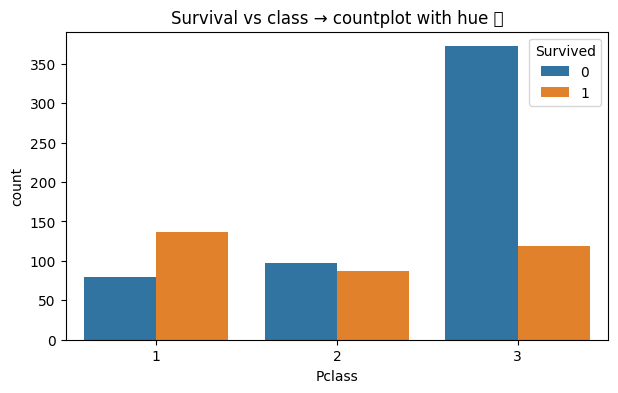

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
# Survival vs class → countplot with hue ✅
plt.figure(figsize=(7,4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival vs class → countplot with hue ✅")
plt.show()


d:\NEW_LEARNING_FOR_MY_FUTURE\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


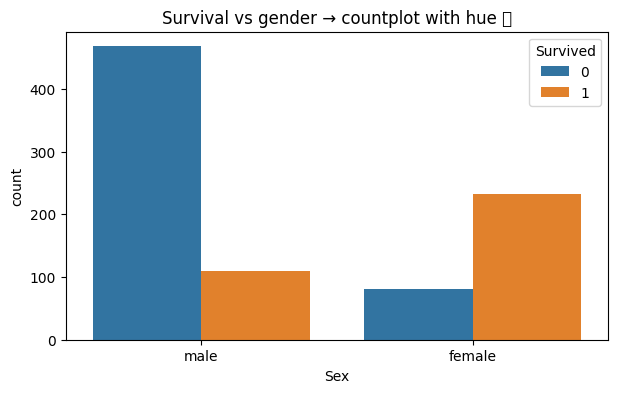

In [51]:
# Survival vs gender → countplot with hue ✅
plt.figure(figsize=(7,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival vs gender → countplot with hue ✅")
plt.show()

d:\NEW_LEARNING_FOR_MY_FUTURE\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


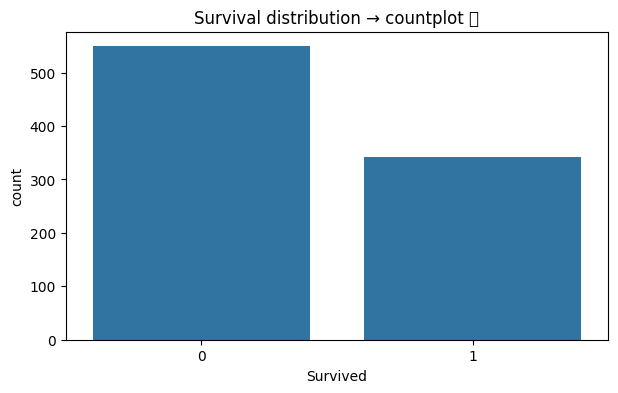

In [54]:
# Survival distribution → countplot ✅
plt.figure(figsize=(7,4))
sns.countplot(x="Survived",data=df)
plt.title("Survival distribution → countplot ✅")
plt.show()

C:\Users\mages\AppData\Local\Temp\ipykernel_7896\3965158641.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Survived", data=df, palette="Set2")


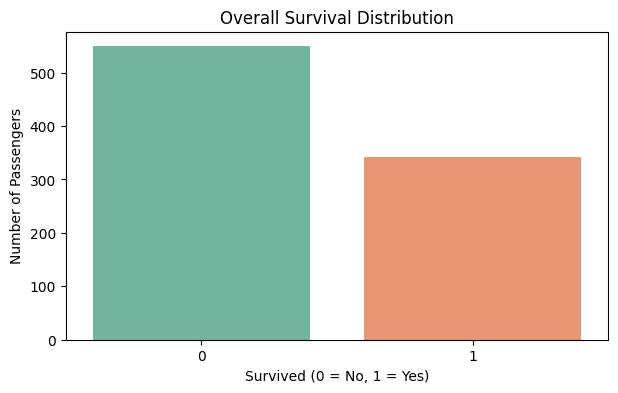

In [55]:
plt.figure(figsize=(7,4))
sns.countplot(x="Survived", data=df, palette="Set2")

plt.title("Overall Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

Bonus 1: Age impact


Divide passengers into:

Child (<18)

Adult (18–60)

Senior (>60)

Which group survived more?
################################

In [57]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [ ]:
Child_passengers = len(df[(df["Survived"]==1) & (df["Age"]<18)])
Adult_passengers = len(df[(df["Survived"]==1) & df["Age"].between(18,60)])
Senior_passengers = len(df[(df["Survived"]==1) & (df["Age"]>60)])
print(Child_passengers)
print(Adult_passengers)
print(Senior_passengers)
passenger_ships_survive = {"child_passengers":Child_passengers,"Adult_passengers":Adult_passengers,"Senior_passengers":Senior_passengers}
print("Which group survived more? \n",max(passenger_ships_survive , key=passenger_ships_survive.get))
"""
61
276
5
Which group survived more? 
 Adult_passengers

"""


61
276
5
Which group survived more? 
 Adult_passengers


In [71]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,18,60,100], labels=["Child","Adult","Senior"])

In [72]:
df.groupby("AgeGroup")["Survived"].mean() * 100

C:\Users\mages\AppData\Local\Temp\ipykernel_7896\400615327.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean() * 100


AgeGroup
Child     50.359712
Adult     36.575342
Senior    22.727273
Name: Survived, dtype: float64

In [ ]:
df.groupby(["Sex", "Pclass"])["Survived"].mean() * 100

"""
Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64
"""

Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64

In [ ]:
df.groupby(["Sex", "Pclass"])["Survived"].mean().unstack() * 100

"""
Pclass	1	2	3
Sex			
female	96.808511	92.105263	50.000000
male	36.885246	15.740741	13.54466
"""

Pclass,1,2,3
Sex,,,
female,96.808511,92.105263,50.000000
male,36.885246,15.740741,13.544669


# final EDA process understanding

This is interview-level answer

You can confidently say:

“Survival on the Titanic was strongly influenced by gender and class. Females had significantly higher survival rates across all classes, but survival decreased as class decreased. This shows that while gender was the dominant factor, socio-economic status also played an important role.”